# $T_2^*$ Ramsey Characterization
$T_2^*$ Ramsey Experiment is able to determine two properties of a qubit - _Ramsey_ or _Detuning Frequency_ and $T_2^*$ <br>
_Detuning Frequency_ is the difference between frequency used for the control rotation pulses and the qubit transition frequency. <br>
$T_2^*$ represents the rate of decay toward a mixed state, when the qubit is initialized to the $\ket{1}$ state. It is the dephasing time (transverse relaxation time) of the qubit on the Bloch sphere as a result of both energy relaxation and pure dephasing in the transverse plane. $T_2^*$ is sensitive to inhomogenous broadening, which is a result from a distribution of transition frequencies.

In [331]:
#import libraries
import numpy as np
from qiskit import QuantumCircuit, transpile

### Circuit Setup

In [332]:
def ramsey_circuits(delay_s: list[int], detuning_hz: float, backend_dt: float):
    circuits=[]
    for d in delay_s:
        delay_dt = int(np.round(d / backend_dt))

        qc = QuantumCircuit(1, 1)
        qc.sx(0)
        qc.delay(delay_dt, 0, unit="dt")
        qc.rz(2 * np.pi * detuning_hz * d, 0)  # phase ramp (virtual detuning)
        qc.sx(0)
        qc.measure(0, 0)

        circuits.append(qc)
    return circuits

### Model
Standard Ramsey Model:
\begin{equation}
    P(\tau) = A e^{- \tau / T_2^*}cos(2\pi f \tau+\phi) + B
\end{equation}
where $\tau$: delay before measurement, $T_2^*$: dephasing time, $A$: amplitude of oscillations, $f$: detuning frequency, $\phi$: initial phase offset. $B$ is a readout error baseline shift.<br>

In [333]:
def model(t, A, T2s, f_hz, phi, B):
    return B + 0.5 * A * np.exp(-t / T2s) * np.cos(2 * np.pi * f_hz * t + phi)

### Simulator Setup

In [334]:
#Simulator
from qiskit_aer import AerSimulator
from qiskit_aer.noise import NoiseModel
from qiskit_ibm_runtime.fake_provider import FakePerth

#Create a pure relaxation noise model
noise_model = NoiseModel.from_backend(FakePerth(), thermal_relaxation=True, gate_error=False, readout_error=False)
#Create backend simulator
backend = AerSimulator.from_backend(FakePerth(), noise_model=noise_model)

### Simulator Experiment

In [335]:
#Use FakePerth's T_2
qubit0_t2 = FakePerth().qubit_properties(0).t2
print(f"FakePerth Qubit 0\'s T2: {qubit0_t2} s")

#Setting waiting time intervals in seconds
delays_sim = np.arange(1e-6, 50e-6, 2e-6) #from ibm document
detuning_hz = 110000 #Hz

circuits_sim = ramsey_circuits(delays_sim, detuning_hz, FakePerth().dt)

job_sim = backend.run(circuits_sim, shots=100)
results_sim = job_sim.result()

FakePerth Qubit 0's T2: 9.506662329992108e-05 s


### Simulation Results

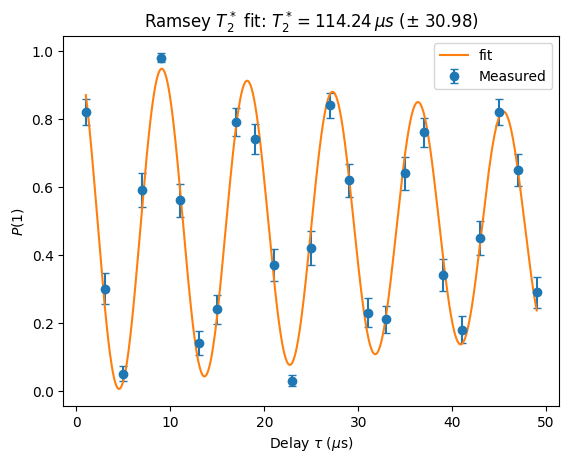


Fit Results:
A   = 1.000000 ± 0.046470
T2* = 1.142408e-04 s ± 3.10e-05 s
f   = 1.100000e+05 Hz ± 5.12e+02 Hz
phi = -0.006484 rad ± 8.01e-02 rad
B   = 0.485760 ± 9.91e-03


In [336]:
from scipy.optimize import curve_fit
import matplotlib.pyplot as plt

#Extract P(1) for each delay
p1s = []
p_errs = []
for i in range(len(delays_sim)):
    counts = results_sim.get_counts(i)
    shots = sum(counts.values())
    pi = counts.get('1', 0) / shots
    p1s.append(pi)
    err = np.sqrt(pi*(1-pi)/shots) #Error
    p_errs.append(err)
p1s = np.array(p1s)
p_errs = np.array(p_errs)

#Fit and Error evaluation
#Initial guesses: (from ibm document)
A0 = 0.5
T20 = 20e-6
f0 = detuning_hz
phi0 = 0.0
B0 = 0.5

p0 = [A0, T20, f0, phi0, B0]

# bounds must match (A, T2s, f, phi, B)
lower = [0.0,   1e-9,  f0, -2*np.pi, 0.0]
upper = [1.0,   np.inf, f0*1000,  2*np.pi, 1.0]
bounds = (lower, upper)

params, cov = curve_fit(model, delays_sim, p1s, p0=p0, sigma=p_errs, bounds=bounds, maxfev=20000)
A, T2s, f, phi, B = params
perr = np.sqrt(np.diag(cov))
A_err, T2s_err, f_err, phi_err, B_err = perr

# Plot
tt = np.linspace(delays_sim.min(), delays_sim.max(), 800)
plt.figure()
plt.errorbar(delays_sim * 1e6, p1s, yerr=p_errs, fmt='o', capsize=3, label="Measured")
plt.plot(tt * 1e6, model(tt, A, T2s, f, phi, B), "-", label="fit")
plt.xlabel(r"Delay $\tau$ ($\mu$s)")
plt.ylabel(r"$P(1)$")
plt.title(rf"Ramsey $T_2^*$ fit: $T_2^*={T2s*1e6:.2f}\,\mu s$ (± {T2s_err*1e6:.2f})")
plt.legend()
plt.show()

print("\nFit Results:")
print(f"A   = {A:.6f} ± {A_err:.6f}")
print(f"T2* = {T2s:.6e} s ± {T2s_err:.2e} s")
print(f"f   = {f:.6e} Hz ± {f_err:.2e} Hz")
print(f"phi = {phi:.6f} rad ± {phi_err:.2e} rad")
print(f"B   = {B:.6f} ± {B_err:.2e}")

### Real Backend Setup

In [337]:
#Real Backend
from qiskit.transpiler import generate_preset_pass_manager
from qiskit_ibm_runtime import QiskitRuntimeService
from qiskit_ibm_runtime import SamplerV2 as Sampler

service = QiskitRuntimeService()
backend = service.backend("ibm_torino") #This is least busy when I am working on this
print("Using backend: ",backend.name)
dt = backend.configuration().dt # seconds per dt tick
print("dt (ns)      =", dt * 1e9)

management.get:WARNING:2026-02-19 16:16:55,089: Loading default saved account


Using backend:  ibm_torino
dt (ns)      = 4.0


### Experiment Setup

In [339]:
#Setting waiting time intervals
delays = np.arange(1e-6, 50e-6, 2e-6) #from ibm document
detuning_hz = 110000 #Hz

circuits = ramsey_circuits(delays, detuning_hz, dt)

#Use the same physical qubit(Qubit 100)
physical = 100
transpiled = transpile(
    circuits,
    backend=backend,
    optimization_level=1,
    initial_layout=[physical],
)

sampler = Sampler(mode=backend)
job = sampler.run(circuits, shots=100)
results = job.result()

### Plot

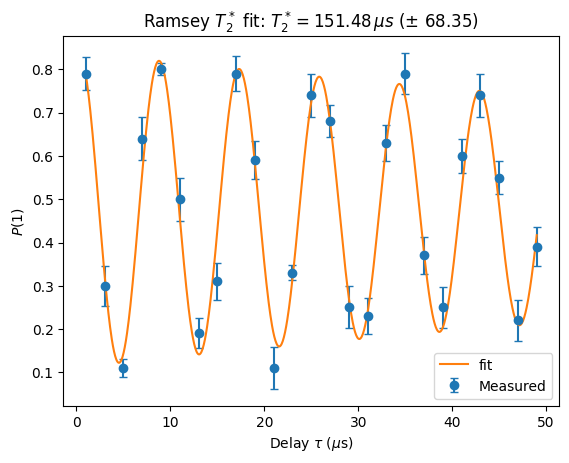


Fit Results:
A   = 0.728913 ± 0.041238
T2* = 1.514805e-04 s ± 6.83e-05 s
f   = 1.172741e+05 Hz ± 5.34e+02 Hz
phi = -0.203273 rad ± 9.12e-02 rad
B   = 0.475822 ± 8.52e-03


In [342]:
#Extract P(1) for each delay
p1 = []
p_err = []
for i in range(len(delays)):
    counts = results[i].join_data().get_counts() # merges all classical register
    shots = sum(counts.values())
    pi = counts.get('1', 0) / shots
    p1.append(pi)
    err = np.sqrt(pi*(1-pi)/shots) #Error
    p_err.append(err)
p1 = np.array(p1)
p_errs = np.array(p_errs)

#Fit and Error evaluation
#Initial guesses: (from ibm document)
A0 = 0.5
T20 = 20e-6
f0 = detuning_hz
phi0 = 0.0
B0 = 0.5

p0 = [A0, T20, f0, phi0, B0]

# bounds must match (A, T2s, f, phi, B)
lower = [0.0,   1e-9,  f0, -2*np.pi, 0.0]
upper = [1.0,   np.inf, f0*1000,  2*np.pi, 1.0]
bounds = (lower, upper)

params, cov = curve_fit(model, delays, p1, p0=p0, sigma=p_errs, bounds=bounds, maxfev=20000)
A, T2s, f, phi, B = params
perr = np.sqrt(np.diag(cov))
A_err, T2s_err, f_err, phi_err, B_err = perr

# Plot
tt = np.linspace(delays.min(), delays.max(), 800)
plt.figure()
plt.errorbar(delays * 1e6, p1, yerr=p_errs, fmt='o', capsize=3, label="Measured")
plt.plot(tt * 1e6, model(tt, A, T2s, f, phi, B), "-", label="fit")
plt.xlabel(r"Delay $\tau$ ($\mu$s)")
plt.ylabel(r"$P(1)$")
plt.title(rf"Ramsey $T_2^*$ fit: $T_2^*={T2s*1e6:.2f}\,\mu s$ (± {T2s_err*1e6:.2f})")
plt.legend()
plt.show()

print("\nFit Results:")
print(f"A   = {A:.6f} ± {A_err:.6f}")
print(f"T2* = {T2s:.6e} s ± {T2s_err:.2e} s")
print(f"f   = {f:.6e} Hz ± {f_err:.2e} Hz")
print(f"phi = {phi:.6f} rad ± {phi_err:.2e} rad")
print(f"B   = {B:.6f} ± {B_err:.2e}")